In [1]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

sim_name = f"SunMod_1k"
# sim_name = f"SunMod_2k"
sim_folder = f"sim_output/{sim_name}"

fig_folder = f"figures_local/{sim_name}"
Cl_folder = f"Shared/Cls"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)

#! Broken halos: either snapshot info missing or anomalous number densities
exclude_nums = jnp.array([
    20,  # halo with missing/broken snapshot info
    23,  # halo with anomalous number densities (~0s on almost all pixels)
    24,  # anomalous "compactified into 1 cell" DM halo
    25,  # anomalous "compactified into 1 cell" DM halo
])
halo_nums = [x for x in range(1, 31) if x not in exclude_nums]

# Fermi-Dirac distribution assumption
dens_folder = f"sim_output/Dopri5_1k"
# note: total densities are computed for length 50 mass range
pix_dens_FD = jnp.load(f"{dens_folder}/pixel_densities.npy")[tuple(halo_nums),...]
tot_dens_FD = jnp.load(f"{dens_folder}/total_densities.npy")[tuple(halo_nums),...]

# Testing functions

## Momentum transformation function

In [ ]:
@jax.jit
def transform_momenta_to_orig_frame(p_vec, boost_vec, masses=None):
    """
    Transform momentum vectors to original frame using proper Lorentz transformation
    
    Args:
        p_vec: Momentum vectors with shape (..., 3)
        boost_vec: Boost velocity vector (3,)
        masses: Mass values for the second dimension
    """

    # Calculate boost magnitude squared
    boost_mag_squared = jnp.sum(boost_vec**2)
    
    # Check if boost is effectively zero
    # For jax, we can use jax.lax.cond for conditional execution
    def zero_boost_case(_):
        p_vec_mag = jnp.sqrt(jnp.sum(p_vec**2, axis=-1))
        return p_vec_mag, p_vec / p_vec_mag[..., None]
    
    def normal_boost_case(_):
        # Calculate Lorentz factor
        boost_mag = jnp.sqrt(jnp.sum(boost_vec**2))
        Lf = 1/jnp.sqrt(1 - boost_mag**2)  # Lorentz factor
        
        # Calculate momentum magnitude
        p_mag = jnp.sqrt(jnp.sum(p_vec**2, axis=-1))
        
        # Calculate energy
        if masses is not None:
            # Ensure masses is properly dimensioned for this specific p_vec
            # If p_vec has shape (1, 5, 768, 1000, 3) and masses has shape (5,)
            # We want to create energy with shape (1, 5, 768, 1000)
            E = jnp.sqrt(p_mag**2 + jnp.reshape(masses, (1, -1, 1, 1))**2)
        else:
            # Massless case (E = p)
            E = p_mag
        
        # Transform momentum via p⃗' = γ(p⃗ - Ev⃗)
        p_orig_vec = Lf * (p_vec - E[..., None]*boost_vec)
        
        # Get magnitude and unit vectors
        p_orig_mag = jnp.sqrt(jnp.sum(p_orig_vec**2, axis=-1))
        p_orig_unit = p_orig_vec / p_orig_mag[..., None]
        
        return p_orig_mag, p_orig_unit
    
    # Use jax.lax.cond to handle the special case
    return jax.lax.cond(
        boost_mag_squared < 1e-10,  # Threshold for "effectively zero"
        zero_boost_case,
        normal_boost_case,
        operand=None
    )


#region: Boost velocities
# Units used for frame/boost related quantities
Ev_unit = Params.km/Params.s

# Need Earth velocities relative to both:
# 1. Galactic Centre (GC) frame (includes solar system motion)
# (order of 250 km/s)
_, _, Ev_GC = SimUtil.SunEarthGC_frame_coords_posvel(
    2024, Earth_rel_Sun=False)
Ev_GC_boost = Ev_GC*Ev_unit
# 2. Sunlock (SL) frame (i.e. motion of Earth relative to only Sun)
# (order of 30 km/s)
_, _, Ev_SL = SimUtil.SunEarthGC_frame_coords_posvel(
    2024, Earth_rel_Sun=True)
Ev_SL_boost = Ev_SL*Ev_unit

# Load velocities from day simulations (these are in "SunLock" frame)
v_unit = Params.kpc/Params.s
fpath = "sim_output/SunNoG/NoSun_vectors/vectors_day1.npy"
day_v = jnp.load(fpath)[..., 3:][None, ...]*v_unit
# (halos, Npix, p_num, 2, 3)
#endregion


# Momenta before transformation
_, p_pre_vec, *_ = Utils.sim_vels_to_sorted_z0z4_vec(
    day_v/v_unit,  # functions expects kpc/s units 
    nu_m_picks, 
    merge_last_axes=False, 
    args=Params()
)
# print(p_pre_vec.shape)
# (1, masses, Npix, p_num, 3)

# Momenta after transformation
p_aft_mag, p_aft_unit = transform_momenta_to_orig_frame(
    p_vec=p_pre_vec, boost_vec=Ev_SL_boost[0], masses=nu_m_picks)
    # p_vec=p_pre_vec, boost_vec=jnp.zeros(3), masses=nu_m_picks)
# print(p_aft_mag.shape, p_aft_unit.shape)
# (1, masses, Npix, p_num), (1, masses, Npix, p_num, 3)

### Test: invariant mass (fails at high boost above ~0.5c)

In [ ]:
def test_invariant_mass(p_vec, masses, boost_vec):
    """
    Test relativistic invariance for particles with different masses and print results.
    
    Args:
        p_vec: Momentum vectors with shape (1, masses, Npix, p_num, 3)
        masses: Array of mass values corresponding to the masses dimension
        boost_vec: Boost velocity vector (3,)
    """
    print("\n" + "="*80)
    print(f"INVARIANT MASS TEST RESULTS")
    print(f"Boost vector: [{boost_vec[0]:.4f}, {boost_vec[1]:.4f}, {boost_vec[2]:.4f}]")
    print(f"Boost magnitude: {np.linalg.norm(boost_vec):.4f}c")
    print(f"Lorentz factor (γ): {1/np.sqrt(1 - np.sum(boost_vec**2)):.4f}")
    print("="*80)
    print(f"{'Mass':<10} {'Original':<12} {'Transformed':<12} {'Abs Diff':<12} {'Rel Diff':<12} {'Result':<10}")
    print("-"*80)
    
    # Loop through each mass
    for m_idx, mass in enumerate(masses):
        # Extract momentum vectors for this mass
        p_vec_m = p_vec[0, m_idx]  # Shape: (Npix, p_num, 3)
        
        # Calculate momentum magnitudes
        p_mag = jnp.linalg.norm(p_vec_m, axis=-1)  # Shape: (Npix, p_num)
        
        # Calculate energy (E^2 = p^2 + m^2)
        energy = jnp.sqrt(p_mag**2 + mass**2)  # Shape: (Npix, p_num)
        
        # Calculate invariant mass in original frame
        m_squared_orig = energy**2 - p_mag**2  # Should be equal to mass^2

        # Transform to new frame
        p_new_mag, p_new_unit = transform_momenta_to_orig_frame(
            p_vec, boost_vec, masses)  # Add missing dims
        p_new_mag = p_new_mag[0, 0, ...]  # Remove extra dims
        p_new_unit = p_new_unit[0, 0, ...]
        
        # Reconstruct the new momentum vectors
        p_new_vec = p_new_unit * p_new_mag[..., None]
        
        # Calculate energy in new frame (E' = γ(E - v·p))
        Lf = 1/jnp.sqrt(1 - jnp.sum(boost_vec**2))
        p_dot_v = jnp.sum(p_vec_m * boost_vec, axis=-1)
        energy_new = Lf * (energy - p_dot_v)
        
        # Calculate invariant mass in new frame
        m_squared_new = energy_new**2 - jnp.sum(p_new_vec**2, axis=-1)
        
        # Calculate statistics
        mean_orig = jnp.mean(jnp.sqrt(m_squared_orig))
        mean_new = jnp.mean(jnp.sqrt(m_squared_new))
        abs_diff = jnp.abs(mean_new - mean_orig)
        rel_diff = abs_diff / mean_orig
        
        # Determine result
        result = "PASS" if rel_diff < 1e-5 else "FAIL"
        
        # Print results
        print(f"{mass:<10.4e} {mean_orig:<12.6f} {mean_new:<12.6f} {abs_diff:<12.6e} {rel_diff:<12.6e} {result:<10}")
    
    print("="*80)
    print("Note: Test passes if relative difference < 1e-5")
    print("="*80 + "\n")

test_invariant_mass(
    p_vec=p_pre_vec, masses=nu_m_picks, boost_vec=Ev_GC_boost[0]*1000)

### Test: invariant mass, single particle (holds for any boost)

In [ ]:
mass = 1.0*Params.eV  # A significant mass value
p_vec = np.array([3.15, 0.0, 0.0])*Params.T_CNB
boost_vec = Ev_GC_boost[0]*1000

# Calculate energy
p_mag = np.linalg.norm(p_vec)
energy = np.sqrt(p_mag**2 + mass**2)

# Rest mass squared (invariant)
m_squared = energy**2 - p_mag**2
print(f"Original rest mass squared: {m_squared} (should be {mass**2})")

# Lorentz factor
gamma = 1/np.sqrt(1 - np.sum(boost_vec**2))

# Transform energy and momentum
p_dot_v = np.dot(p_vec, boost_vec)
energy_new = gamma * (energy - p_dot_v)

p_new = p_vec + (gamma-1)*(p_dot_v/np.sum(boost_vec**2))*boost_vec - gamma*energy*boost_vec
p_new_mag = np.linalg.norm(p_new)

# New rest mass squared
m_squared_new = energy_new**2 - p_new_mag**2
print(f"New rest mass squared: {m_squared_new}")
print(f"Difference: {m_squared_new - m_squared}")
print(f"Relative difference: {(m_squared_new - m_squared)/m_squared}")

### Test: to and fro transformation (passes for any boost)

In [ ]:
def test_back_transformation(p_vec, boost_vec):
    # Forward transformation
    p_new_mag, p_new_unit = transform_momenta_to_orig_frame(p_vec, boost_vec)
    p_new_vec = p_new_unit * p_new_mag[..., None]
    
    # Backward transformation with negative boost
    p_orig_mag, p_orig_unit = transform_momenta_to_orig_frame(p_new_vec, -boost_vec)
    p_orig_vec = p_orig_unit * p_orig_mag[..., None]
    
    # Compare with original
    print(jnp.unique(jnp.allclose(p_vec, p_orig_vec, rtol=1e-5)))

test_back_transformation(p_vec=p_pre_vec, boost_vec=Ev_GC_boost[0])
test_back_transformation(p_vec=p_pre_vec, boost_vec=Ev_GC_boost[0]*100)
test_back_transformation(p_vec=p_pre_vec, boost_vec=Ev_GC_boost[0]*1000)

## Euler Angles

In [ ]:
def get_direct_rotation(earth_position, cell_position):
    """
    Directly construct a rotation matrix that rotates earth_position to cell_position.
    """
    # Normalize both vectors
    earth_norm = earth_position / jnp.linalg.norm(earth_position)
    cell_norm = cell_position / jnp.linalg.norm(cell_position)
    
    # Calculate the rotation axis
    axis = jnp.cross(earth_norm, cell_norm)
    axis_norm = jnp.linalg.norm(axis)
    
    # Handle parallel or antiparallel vectors
    if axis_norm < 1e-10:
        # If vectors are parallel, no rotation needed
        if jnp.dot(earth_norm, cell_norm) > 0:
            return jnp.eye(3)
        # If vectors are antiparallel, rotate 180° around z-axis
        else:
            return jnp.array([[-1, 0, 0], [0, -1, 0], [0, 0, 1]])
    
    # Normalize the axis
    axis = axis / axis_norm
    
    # Calculate the rotation angle
    cos_angle = jnp.dot(earth_norm, cell_norm)
    sin_angle = axis_norm
    
    # Build rotation matrix using Rodrigues' formula
    K = jnp.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    
    R = jnp.eye(3) + sin_angle * K + (1 - cos_angle) * jnp.matmul(K, K)
    return R


def test_rotation_visualization(
        cell_positions, selected_cell_idx=0, 
        earth_position=jnp.array([8.127, 0., 0.]), azim=-60, elev=30):
    """
    Create a 3D visualization of the coordinate system with the Galactic Center (GC) at origin,
    Earth position, selected cell position, rotated Earth position, and coordinate axes.
    Includes a semi-transparent xy-plane and projection lines.
    
    Args:
        cell_positions: Array of cell positions with shape [halos, 3]
        selected_cell_idx: Index of the cell to visualize
        earth_position: Earth position vector [x, y, z]
        azim: Azimuth angle for 3D plot view
        elev: Elevation angle for 3D plot view
    """
    # Create figure
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Get the selected cell and its properties
    selected_cell = cell_positions[selected_cell_idx]
    
    # Calculate distances
    earth_distance = jnp.linalg.norm(earth_position)
    cell_distance = jnp.linalg.norm(selected_cell)
    
    # Get rotation matrix for this cell
    R = get_direct_rotation(earth_position, selected_cell)
    
    # Apply rotation to Earth position
    # rotated_earth = jnp.matmul(R, earth_position)
    rotated_earth = jnp.einsum('ij,j->i', R, earth_position)
    
    # Scale rotated Earth to match cell distance
    scale_factor = cell_distance / earth_distance
    rotated_earth_scaled = rotated_earth * scale_factor
    
    # Calculate viewing range
    max_range = max(jnp.linalg.norm(earth_position), jnp.linalg.norm(selected_cell)) * 1.5
    
    # Add semi-transparent xy-plane
    xx, yy = np.meshgrid(np.linspace(-max_range, max_range, 10), 
                        np.linspace(-max_range, max_range, 10))
    zz = np.zeros_like(xx)
    
    # Plot the xy-plane with grid lines
    ax.plot_surface(xx, yy, zz, alpha=0.2, color='gray', edgecolor='gray', 
                   linewidth=0.5, shade=False)
    
    # Plot the GC at origin
    ax.scatter([0], [0], [0], color='black', s=100, label='Galactic Center')
    
    # Plot Earth position
    ax.scatter([earth_position[0]], [earth_position[1]], [earth_position[2]], 
               color='blue', s=80, label='Earth')
    
    # Plot the selected cell
    ax.scatter([selected_cell[0]], [selected_cell[1]], [selected_cell[2]], 
               color='purple', s=100, marker='s', label='Selected Cell')
    
    # Plot rotated Earth position
    ax.scatter([rotated_earth[0]], [rotated_earth[1]], [rotated_earth[2]], 
               color='green', s=80, label='Rotated Earth')
    
    # Plot scaled rotated Earth position
    ax.scatter([rotated_earth_scaled[0]], [rotated_earth_scaled[1]], [rotated_earth_scaled[2]], 
               color='lime', s=80, label='Scaled Rotated Earth')
    
    # Add projections to xy-plane
    # Draw projection points
    cell_projection = [selected_cell[0], selected_cell[1], 0]
    earth_projection = [earth_position[0], earth_position[1], 0]
    rot_earth_projection = [rotated_earth[0], rotated_earth[1], 0]
    scaled_rot_earth_projection = [rotated_earth_scaled[0], rotated_earth_scaled[1], 0]
    
    # Plot projection points
    ax.scatter(*cell_projection, color='purple', s=50, alpha=0.5, marker='o')
    ax.scatter(*earth_projection, color='blue', s=40, alpha=0.5, marker='o')
    ax.scatter(*rot_earth_projection, color='green', s=40, alpha=0.5, marker='o')
    ax.scatter(*scaled_rot_earth_projection, color='lime', s=40, alpha=0.5, marker='o')
    
    # Connect points to their projections with dotted lines
    ax.plot([selected_cell[0], cell_projection[0]], 
            [selected_cell[1], cell_projection[1]], 
            [selected_cell[2], cell_projection[2]], 
            color='purple', ls=':', alpha=0.7)
    
    ax.plot([earth_position[0], earth_projection[0]], 
            [earth_position[1], earth_projection[1]], 
            [earth_position[2], earth_projection[2]], 
            color='b', ls=':', alpha=0.7)
    
    ax.plot([rotated_earth[0], rot_earth_projection[0]], 
            [rotated_earth[1], rot_earth_projection[1]], 
            [rotated_earth[2], rot_earth_projection[2]], 
            color='g', ls=':', alpha=0.7)
    
    ax.plot([rotated_earth_scaled[0], scaled_rot_earth_projection[0]], 
            [rotated_earth_scaled[1], scaled_rot_earth_projection[1]], 
            [rotated_earth_scaled[2], scaled_rot_earth_projection[2]], 
            color='lime', ls=':', alpha=0.7)
    
    # Add original coordinate system - make vectors larger
    origin = jnp.zeros(3)
    vector_length = max(earth_distance, cell_distance) * 0.3  # Adjust vector length
    ax.quiver(*origin, vector_length, 0, 0, color='r', label='X axis')
    ax.quiver(*origin, 0, vector_length, 0, color='g', label='Y axis')
    ax.quiver(*origin, 0, 0, vector_length, color='b', label='Z axis')
    
    # Add rotated coordinate system
    ax.quiver(*origin, R[0, 0]*vector_length, R[1, 0]*vector_length, R[2, 0]*vector_length, 
              color='r', linestyle='--', alpha=0.7, label='X\' axis')
    ax.quiver(*origin, R[0, 1]*vector_length, R[1, 1]*vector_length, R[2, 1]*vector_length, 
              color='g', linestyle='--', alpha=0.7, label='Y\' axis')
    ax.quiver(*origin, R[0, 2]*vector_length, R[1, 2]*vector_length, R[2, 2]*vector_length, 
              color='b', linestyle='--', alpha=0.7, label='Z\' axis')
    
    # Connect points with lines from origin
    ax.plot([0, earth_position[0]], [0, earth_position[1]], [0, earth_position[2]], 'b--')
    ax.plot([0, selected_cell[0]], [0, selected_cell[1]], [0, selected_cell[2]], color='purple', ls='--')
    ax.plot([0, rotated_earth[0]], [0, rotated_earth[1]], [0, rotated_earth[2]], 'g--')
    ax.plot([0, rotated_earth_scaled[0]], [0, rotated_earth_scaled[1]], [0, rotated_earth_scaled[2]], color='lime', ls='-')
    
    # Set limits centered on origin
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])
    
    # Set the view angle
    ax.view_init(elev=elev, azim=azim)
    
    # Add labels
    ax.set_xlabel('X (kpc)')
    ax.set_ylabel('Y (kpc)')
    ax.set_zlabel('Z (kpc)')
    ax.set_title(f'Rotation Visualization for Cell {selected_cell_idx}')
    ax.legend(loc='best')
    
    # Calculate metrics for annotation
    direction_alignment = jnp.dot(rotated_earth/jnp.linalg.norm(rotated_earth), 
                                 selected_cell/jnp.linalg.norm(selected_cell))
    distance_to_cell = jnp.linalg.norm(rotated_earth_scaled - selected_cell)
    
    # Get Euler angles for annotation
    zAngle = jnp.arctan2(selected_cell[1], -selected_cell[0])
    yAngle = jnp.arctan2(-selected_cell[2], jnp.linalg.norm(selected_cell[:2]))
    
    # Annotations for clarity
    cell_pos_str = f"Cell: ({selected_cell[0]:.2f}, {selected_cell[1]:.2f}, {selected_cell[2]:.2f})"
    earth_pos_str = f"Earth: ({earth_position[0]:.2f}, {earth_position[1]:.2f}, {earth_position[2]:.2f})"
    rot_earth_str = f"Rotated Earth: ({rotated_earth[0]:.2f}, {rotated_earth[1]:.2f}, {rotated_earth[2]:.2f})"
    scaled_earth_str = f"Scaled Rotated Earth: ({rotated_earth_scaled[0]:.2f}, {rotated_earth_scaled[1]:.2f}, {rotated_earth_scaled[2]:.2f})"
    angle_str = f"Euler Angles: z={np.degrees(zAngle):.2f}°, y={np.degrees(yAngle):.2f}°"
    metrics_str = f"Direction Alignment: {direction_alignment:.6f} | Distance to Cell: {distance_to_cell:.6f} kpc"
    z_height_str = f"Z-heights: Cell: {selected_cell[2]:.2f} kpc, Earth: {earth_position[2]:.2f} kpc, Scaled Rotated Earth: {rotated_earth_scaled[2]:.2f} kpc"
    
    plt.figtext(0.5, 0.01, 
                f"{cell_pos_str} | {earth_pos_str}\n{rot_earth_str} | {scaled_earth_str}\n{angle_str}\n{metrics_str}\n{z_height_str}", 
                ha="center", fontsize=10, bbox={"facecolor":"wheat", "alpha":0.5, "pad":5})
    
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    return fig


# Generate some test cell positions
np.random.seed(42)
num_cells = 10
cell_positions = np.random.uniform(-10, 10, size=(num_cells, 3))

# Add specific test cases
cell_positions[0] = np.array([5.0, 5.0, 5.0])      # pos. 45° octant 
cell_positions[1] = np.array([5.0, 5.0, 0.0])       # xy-plane 45°
cell_positions[2] = np.array([7.0, 3.0, 4.0])       # general position
cell_positions[3] = np.array([-6.0, -2.0, -5.0])    # negative components
cell_positions[4] = np.array([-8.127, 0.0, 0.0])    # antipodal to Earth

# Earth position
earth_position = jnp.array([3.127, 0.0, 0.0])

# Create visualization
fig = test_rotation_visualization(
    cell_positions, 
    selected_cell_idx=0,  # Try different indices to test
    earth_position=earth_position,
    azim=-60,  # Change these to adjust view angle, orig -60
    elev=30  # orig 30
)

# Plotting annual modulations

*(densities computed in separate .py script)*

## Individual modulation curves, testing results

In [ ]:
# region: preamble
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

#! Broken halos: either snapshot info missing or anomalous number densities
exclude_nums = jnp.array([
    20,  # halo with missing/broken snapshot info
    23,  # halo with anomalous number densities (~0s on almost all pixels)
    24,  # anomalous "compactified into 1 cell" DM halo
    25,  # anomalous "compactified into 1 cell" DM halo
])
halo_nums = [x for x in range(1, 31) if x not in exclude_nums]

# Fermi-Dirac distribution assumption
dens_folder = f"sim_output/Dopri5_1k"
# note: total densities are computed for length 50 mass range
pix_dens_FD = jnp.load(f"{dens_folder}/pixel_densities.npy")[tuple(halo_nums),...]
tot_dens_FD = jnp.load(f"{dens_folder}/total_densities.npy")[tuple(halo_nums),...]
# endregion


### =============== ###
### No Sun versions ###
### =============== ###

# region: No Sun versions, and old SunLock frame results (outdated)
# No Sun with FD PSD, no boost/rotation, see if no error in data structure
# sim_name = f"SunNoG"
# prefix = "NoG"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# note: log_yaxis=False, y_lims=(-0.001, 0.0001) for mode='densities', 
# otherwise data not visible
# result: nu_dens all flat at or near zero due to no grav and FD PSD

# No Sun with gravPSD, no boost, no rot, see if number densities match
# sim_name = f"SunNoG"
# prefix = "NoG_noBnoR"
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"
# result: nu_dens match [0.999, 0.997, 0.994, 1.023, 1.1097] for nu_m_picks
# note: routine seems good/stable enough for our first 4 masses of interest

### The following two I don't think make sense now that I realised we can move 
### Sun around, and we avoid boost confusions all together
# No Sun with gravPSD, with boost, no rot, see effect of MW boost only
# sim_name = f"SunNoG"
# prefix = "NoG"
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"
# result: rel_vel="MW" results in similar shape as bound case in Safdi

# No Sun with gravPSD, with boost, no rot, see effect of CNB boost only
# sim_name = f"SunNoG"
# prefix = "NoG"
# suffix = "_grav_PSD_Earth_frame_wrtCNB_int_pixels"
# result: rel_vel="CNB" results in similar shape as unbound case in Safdi

# For analytical Safdi method, switching relative velocities changes the peak 
# locations and heights (see figures in figures_loca/SunMod_1k).
# Peak locations are similar to our wrtMW and wrtCNB cases, but heights differ.
# endregion


### =============== ###
### Sun 1k versions ###
### =============== ###

# region: old SunLock frame, outdated
# Testing no boost velocities, Dopri5
# sim_name = f"SunMod_1k"
# prefix = "SunDop5_noBoost"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# result: influence of Sun only, max/min coincides with Earth-Sun max/min dist.

# Testing no boost velocities, Dopri8
# sim_name = f"SunMod_1k"
# prefix = "SunDop8_noBoost"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# result: slight deviation from Dopri5, from max~0.008 to 0.01.

# Testing double boost velocities
# sim_name = f"SunMod_1k"
# prefix = "SunDop5_x2Boost"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# result: huge impact of boost velocity value, what does this imply/mean?

# SunMove frame, FD PSD, no boost
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5_noBoost"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# suffix = "_FD_PSD_Earth_frame_wrtCNB_int_pixels"

# (old) TODOs:
# 1. Use SHM vel. distr. as boundary PSD to see if same as bound case in Safdi.
# 2. Use analytical Earth-Sun pos/vel functions instead of astropy, to see if 
#    peak location of SunMoveDop5_noBoost then matches with Safdi.
# 3. Test SunMove_Dopri5_wrtCNB sim folder

# SunMove frame, SHM PSD, no boost
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5_SHM"  # with v_0 = 220 km/s
# prefix = "SunMoveDop5_SHM2"  # with v_0 = 400 km/s
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# endregion

# region: SunMove frame, corrected orbits, then corrected velocities
### New Sun orbit functions, corrected to match with Safdi

# FD PSD
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# note: log_yaxis=False and y_lims=(-0.001, 0.008) for best visibility of data

# SHM PSD, both 220 and 400 km/s for v_0
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5_SHM_220v0"
# prefix = "SunMoveDop5_SHM_400v0"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"

# grav PSD
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5"
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"

# grav PSD
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5_old_SHM_220v0"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"

### New corrected Sun velocity

# FD PSD & SHM PSD
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5_new_Sun_vel"
# prefix = "SunMoveDop5_new_Sun_vel_SHM_220v0"
# prefix = "SunMoveDop5_new_Sun_vel_SHM_400v0"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"

# grav PSD
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5_new_Sun_vel"
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"
# endregion


### ============== ###
### Final versions ###
### ============== ###
#/ showcase

# region: working and final code, all results we want to show in paper

### Validation of functions and methods

# No Sun with gravPSD, see if number densities match
# sim_name = f"SunNoG"
# prefix = "NoG_noBnoR"
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"
# result: nu_dens match [0.999, 0.997, 0.994, 1.023, 1.1097] for nu_m_picks
# note: routine seems good/stable enough for our first 4 masses of interest

### Comparison to Safdi results

# wrtMW folder: SHM PSD
sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5_fin_SHM_220v0"
prefix = "SunMoveDop5_fin_SHM_400v0"
# prefix = "SunMoveDop5_new_Sun_vel_SHM_Xv0"  # 1000 approaches 0.2% mod, but shape gets wonky, assuming framework breaks down or becomes invalid? Or maybe ranges of arrays have to be adjusted
suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# result: the number densities are around -1, when log_y_axis=False
# note: see ..._background notebook, where only bound of Safdi also yields 
#       very low number densities ~0.2 / cm^3

# wrtCNB folder: FD PSD
# note: doesn't make much sense to use wrtMW data and FD PSD, right?
#       we're in the wrong frame then, so we use wrtCNB folder
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5_new_Sun_vel"
# suffix = "_FD_PSD_Earth_frame_wrtCNB_int_pixels"

# note: both our bound and unbound cases match quite well with Safdi's curves

### Full halos results

# wrtMW folder: FD PSD, seeing Sun effect only
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5_new_Sun_vel"
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# note: log_y_axis=False with y_lims=(-0.001, 0.01)

# Main results, grav PSD, wrtMW folder
# sim_name = f"SunMod_1k"
# prefix = "SunMoveDop5_new_Sun_vel"
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"

# Using the wrtCNB folder and grav PSD is wrong, and just to showcase that peak 
# in modulation curves shifts according to relative velocity used as well
# suffix = "_grav_PSD_Earth_frame_wrtCNB_int_pixels"

# endregion


### =========== ###
### Load & Plot ###
### =========== ###

# region: files and printing
sim_folder = f"sim_output/{sim_name}"
fig_folder = f"figures_local/{sim_name}"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
# nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
# nu_m_picks = jnp.array([0.01, 0.05, 0.15, 0.2, 0.3])*Params.eV
nu_m_picks = jnp.array([0.15, 0.2, 0.25, 0.3, 0.01])*Params.eV
simdata = SimData(sim_folder)

print(f"{prefix}{suffix}")
days_nums = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_nums{suffix}.npy")
days_dens = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_dens{suffix}.npy")
print(f"days_dens shape: {days_dens.shape}")
print(days_dens[0,...])
# (days, halos, masses)

# if suffix == "_FD_PSD_int_pixels":
#     print(f"\nSun clustering factors:")
#     print(jnp.mean(days_dens[:,0,:], axis=0)/Params.N0_cm3-1)

halo_num = 5
nu_m_match = jnp.abs(nu_m_range[None, :] - nu_m_picks[:, None]).argmin(axis=-1)
etas_med = np.median(
    tot_dens_FD[:halo_num]/Params.N0_cm3, axis=0)[nu_m_match]
etas_16 = np.percentile(
    tot_dens_FD[:halo_num]/Params.N0_cm3, q=16, axis=0)[nu_m_match]
etas_84 = np.percentile(
    tot_dens_FD[:halo_num]/Params.N0_cm3, q=84, axis=0)[nu_m_match]

etas_stack = jnp.vstack((etas_med,etas_16,etas_84)) - 1

# Compute percentage deviation
etas_med_day_sim = (jnp.median(days_dens[0,...], axis=0)/Params.N0_cm3)
# print((etas_med - etas_med_day_sim)/etas_med*100)
print(f"Day 1 sim is factor {etas_med_day_sim/etas_med} of core sim")
# endregion

SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='densities',
    log_yaxis=False,
    # y_lims=None,
    # y_lims=(1e-5, 1e-2),  # for log
    # y_lims=(-0.001, 0.08),  # for lin
    # y_lims=(-0.001, 0.01),  # for Sun only effect
    pdf_path=f"{fig_folder}/densities_{prefix}{suffix}",
    etas_tuple=etas_stack
)
SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='modulation',
    mod_method="rel",
    pdf_path=f"{fig_folder}/modulation_rel_{prefix}{suffix}",
)
SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='modulation',
    mod_method="avg",
    pdf_path=f"{fig_folder}/modulation_avg_{prefix}{suffix}",
)

## Result 1: Ana vs. Num comparison

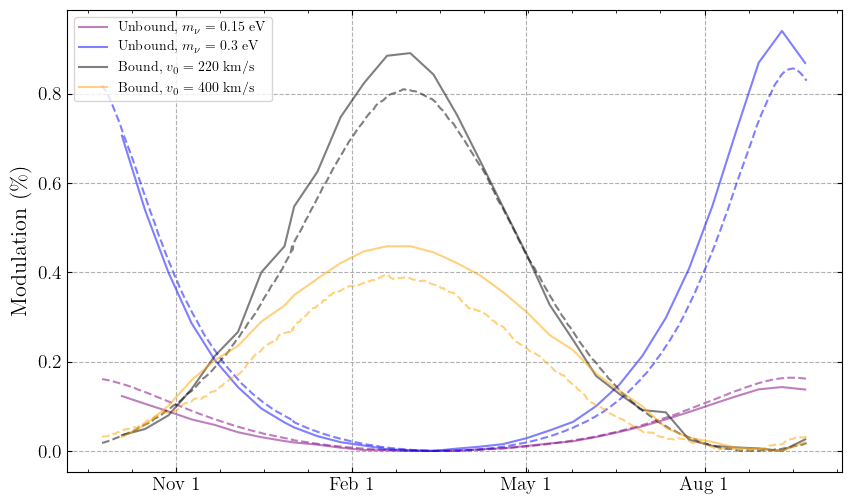

In [ ]:
def plot_mod_comaparison_ana_vs_num(
        density_arrays_analytical, density_arrays_numerical, days_nums,
        cases, fig_folder, start_date_str='09-11', y_lims=None, pdf_str='mod.pdf'):

    fig = plt.figure(figsize=(10, 6))
    fig.tight_layout()
    ax = fig.add_subplot(111)

    # Convert start_date_str to datetime object
    start_date = datetime.strptime(start_date_str, '%m-%d')
    start_day_of_year = start_date.timetuple().tm_yday

    # Generate time points for analytical data (full year)
    days_analytical = jnp.linspace(0, Params.yr, 365)
    
    # Process each case
    for m_nu, bound, v_0, label, _, color, alpha in cases:
        # Construct keys for analytical and numerical data
        if not bound:
            analytical_key = f"annual_densities_analytical_{m_nu}eV_unbound"
            numerical_key = f"annual_densities_numerical_{m_nu}eV_unbound"
        else:
            analytical_key = f"annual_densities_analytical_{v_0/(Params.km/Params.s)}kms_{m_nu}eV_bound"
            numerical_key = f"annual_densities_numerical_{v_0/(Params.km/Params.s)}kms_{m_nu}eV_bound"
        
        # Process analytical data (dashed lines) - full year data
        if analytical_key in density_arrays_analytical:
            densities = density_arrays_analytical[analytical_key]
            
            # Calculate modulation
            min_density = jnp.min(densities)
            mod = (densities - min_density) / (densities + min_density) * 100

            # Shift days to start from the specified date
            shifted_days = (days_analytical/Params.yr*365 - start_day_of_year) % 365 + 1
            sorted_indices = jnp.argsort(shifted_days)
            shifted_days = shifted_days[sorted_indices]
            mod = mod[sorted_indices]

            ax.plot(
                shifted_days, mod, 
                linestyle='dashed', color=color, 
                # label=f"{label} (analytical)", 
                alpha=alpha)
                
        # Process numerical data (solid lines) - only at specific days
        if numerical_key in density_arrays_numerical:
            densities = density_arrays_numerical[numerical_key]
            
            # Since we started from Dec 31st to Jan 1st, we flip array
            densities = jnp.flip(densities, axis=0)

            # Calculate modulation
            min_density = jnp.min(densities)
            mod = (densities - min_density) / (densities + min_density) * 100

            # Shift days to start from the specified date
            shifted_days = (days_nums - start_day_of_year) % 365 + 1
            sorted_indices = jnp.argsort(shifted_days)
            shifted_days = shifted_days[sorted_indices]
            mod = mod[sorted_indices]

            ax.plot(
                shifted_days, mod, 
                linestyle='solid', color=color,
                label=f"{label}", alpha=alpha)

    # Calculate tick positions and labels
    tick_dates = [datetime_date(2000, 11, 1), datetime_date(2000, 2, 1), 
                datetime_date(2000, 5, 1), datetime_date(2000, 8, 1)]
    tick_days = [(d - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1 
                for d in tick_dates]
    tick_labels = ['Nov 1', 'Feb 1', 'May 1', 'Aug 1']
    plt.xticks(tick_days, tick_labels)
    plt.grid(True, which="major", linestyle="dashed")

    # Axis limits
    if y_lims is not None:
        plt.ylim(y_lims[0], y_lims[1])
    
    # Set title and labels
    # plt.title("Annual modulation")
    plt.ylabel(r'Modulation ($\%$)')
    # plt.xlabel('Date')
    
    plt.legend(prop={"size":10})
    plt.savefig(f"{fig_folder}/{pdf_str}", bbox_inches="tight")
    plt.show()
    plt.close()


# region: preamble, file loading
# Load mass files in Safdi analytical framework
m_l = 0.15*Params.eV
m_h = 0.3*Params.eV

cases = [
    (m_l, False, 220.0*Params.km/Params.s, fr'Unbound, $m_\nu = $ {m_l} eV', 'dashed', 'purple', 0.5),
    (m_h, False, 220.0*Params.km/Params.s, fr'Unbound, $m_\nu = $ {m_h} eV', 'dashed', 'blue', 0.5),
    (m_h, True, 220.0*Params.km/Params.s, r'Bound, $v_0 = $ 220 km/s', 'solid', 'black', 0.5),
    (m_h, True, 400.0*Params.km/Params.s, r'Bound, $v_0 = $ 400 km/s', 'solid', 'orange', 0.5)
]

sim_folder = f"sim_output/SunMod_1k"

density_arrays_analytical = {
    f"annual_densities_analytical_{m_l}eV_unbound": jnp.load(f"{sim_folder}/annual_densities_analytical/annual_densities_{m_l}eV_unbound.npy"),
    f"annual_densities_analytical_{m_h}eV_unbound": jnp.load(f"{sim_folder}/annual_densities_analytical/annual_densities_{m_h}eV_unbound.npy"),
    f"annual_densities_analytical_220.0kms_{m_h}eV_bound": jnp.load(f"{sim_folder}/annual_densities_analytical/annual_densities_220.0kms_{m_h}eV_bound.npy"),
    f"annual_densities_analytical_400.0kms_{m_h}eV_bound": jnp.load(f"{sim_folder}/annual_densities_analytical/annual_densities_400.0kms_{m_h}eV_bound.npy")
}

# Bound case, 220 km/s
prefix = "SunMoveDop5_fin_SHM_220v0"
suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"
# Day numbers need only be loaded once
days_nums = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_nums{suffix}.npy")
days_dens_bound220 = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_dens{suffix}.npy")[:,0,-1]
# print(days_nums.shape)
# print(days_dens_bound220[:,0,-1].shape)

# Bound case, 400 km/s
prefix = "SunMoveDop5_fin_SHM_400v0"
days_dens_bound400 = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_dens{suffix}.npy")[:,0,-1]
# print(days_dens_bound400[:,0,-1].shape)

# Unbound case, 0.15 eV and 0.3 eV
prefix = "SunMoveDop5_new_Sun_vel"
suffix = "_FD_PSD_Earth_frame_wrtCNB_int_pixels"
days_dens_unbound = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_dens{suffix}.npy")
# print(days_dens_unbound.shape)

density_arrays_numerical = {
    f"annual_densities_numerical_{m_l}eV_unbound": days_dens_unbound[:,0,0] ,
    f"annual_densities_numerical_{m_h}eV_unbound": days_dens_unbound[:,0,3],
    f"annual_densities_numerical_220.0kms_{m_h}eV_bound": days_dens_bound220,
    f"annual_densities_numerical_400.0kms_{m_h}eV_bound": days_dens_bound400,
}
# endregion


plot_mod_comaparison_ana_vs_num(
    density_arrays_analytical, 
    density_arrays_numerical, 
    days_nums,
    cases,
    fig_folder, 
    start_date_str='09-23', 
    y_lims=None, 
    pdf_str='Mod_comparison_ana_vs_num.pdf')

## Result 2: Total numerical modulation curves

SunMoveDop5_fin_grav_PSD_Earth_frame_wrtMW_int_pixels
days_dens shape: (31, 1, 5)
[[ 69.08325811  79.14001354  92.31059173 108.60782224  56.65277322]]
173 356


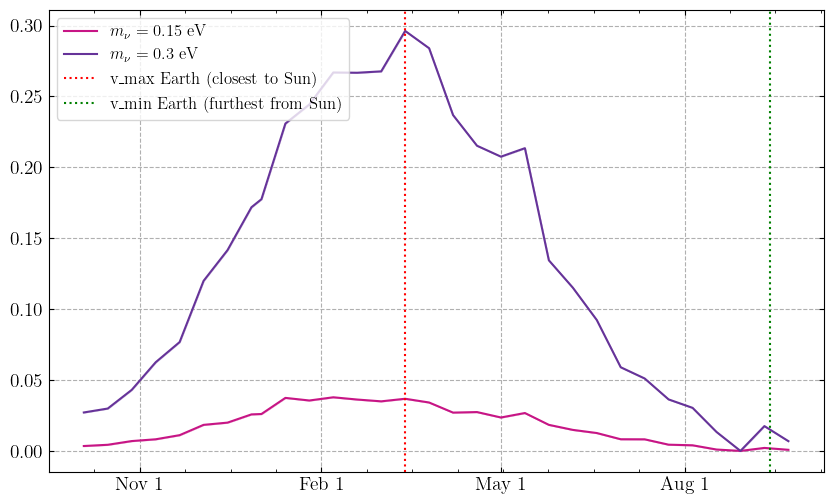

In [ ]:
def plot_modulations_numerical(
        nu_dens_days, simulated_days, nu_m_picks, 
        start_date_str='09-11', mode='modulation', mod_method="", log_yaxis=False, y_lims=None, pdf_path="", etas_tuple=None, args=None):
    
    if args is None:
        args = Params()

    fig = plt.figure(figsize=(10, 6))
    fig.tight_layout()
    ax = fig.add_subplot(111)

    # Convert start_date_str to datetime object
    start_date = datetime.strptime(start_date_str, '%m-%d')

    # Calculate the day of the year for the start date
    start_day_of_year = start_date.timetuple().tm_yday

    # Shift days to start from the specified date
    shifted_days = (simulated_days - start_day_of_year) % 365 + 1
    sorted_indices = jnp.argsort(shifted_days)
    shifted_days = shifted_days[sorted_indices]

    violet_colors = [
        "mediumvioletred", 
        "rebeccapurple",
    ]

    for m_idx, (m_val, color) in enumerate(zip(nu_m_picks, violet_colors)):

        # Select current mass
        nu_dens_m = nu_dens_days[..., m_idx]
        # shape: (days, halos)

        # Since we started from Dec 31st to Jan 1st, we flip array
        nu_dens_m = jnp.flip(nu_dens_m, axis=0)

        if mode == 'densities':
            # Display number over-densities
            mod = (nu_dens_m / args.N0_cm3) - 1

            plt.title("Number densities")

            if log_yaxis:
                ax.set_yscale("log")
                ax.set_ylabel(r'$n_{\nu} / n_{\nu, 0}$')
                # 1+10^X styled y-axis labels, to easily see order of overdensities
                ax.yaxis.set_major_formatter(ticker.FuncFormatter(Utils.y_fmt))

                if m_idx in (0,1,3):
                    plt.axhline(
                        y=etas_tuple[0,m_idx], color=color, 
                        linestyle="dashed", alpha=1)
                    # plt.axhline(
                    #     y=etas_tuple[1,m_idx], color=color, 
                    #     linestyle=":", alpha=1)
                    # plt.axhline(
                    #     y=etas_tuple[2,m_idx], color=color, 
                    #     linestyle=":", alpha=1)

            else:
                if m_idx in (0,1,3):
                    plt.axhline(
                        y=etas_tuple[0,m_idx], color=color, 
                        linestyle="dashed", alpha=1)
                    # plt.axhline(
                    #     y=etas_tuple[1,m_idx], color=color, 
                    #     linestyle=":", alpha=1)
                    # plt.axhline(
                    #     y=etas_tuple[2,m_idx], color=color, 
                    #     linestyle=":", alpha=1)
                
                ax.set_ylabel(r'$n_{\nu} / n_{\nu, 0}$ - 1')
            
            # if m_idx == 0:
            #     plt.axhline(y=Params.N0_cm3, color='k', linestyle=":", label=r"$\Lambda$CDM $n_\nu$")

        else:
            # Compute fractional modulation for each halo

            if mod_method == "rel":
                nu_min = jnp.min(nu_dens_m, axis=0)
                mod = (nu_dens_m - nu_min) / (nu_dens_m + nu_min) * 100
                # ax.set_ylabel(r'Modulation ($\%$)')
            if mod_method == "avg":
                nu_avg = jnp.mean(nu_dens_m, axis=0)
                mod = (nu_dens_m - nu_avg) / nu_avg * 100
                ax.set_ylabel(r'Difference from $\bar{n}_\nu$ ($\%$)')

            # plt.title("Annual modulation")


        # Compute median and 1-sigma band
        median = jnp.median(mod, axis=-1)
        lower = jnp.percentile(mod, 16, axis=-1)
        upper = jnp.percentile(mod, 84, axis=-1)

        # Apply sorting to match shifted_days
        median = median[sorted_indices]
        lower = lower[sorted_indices]
        upper = upper[sorted_indices]

        # Plot median and 1-sigma band
        ax.plot(shifted_days, median, '-', color=color, label=fr"$m_\nu = {m_val}$ eV")
        ax.fill_between(shifted_days, lower, upper, color=color, alpha=0.2)


    # Calculate tick positions and labels
    tick_dates = [datetime_date(2000, 11, 1), datetime_date(2000, 2, 1), 
                datetime_date(2000, 5, 1), datetime_date(2000, 8, 1)]
    tick_days = [(d - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1 for d in tick_dates]
    tick_labels = ['Nov 1', 'Feb 1', 'May 1', 'Aug 1']

    plt.xticks(tick_days, tick_labels)

    # March 12th (2000,3,12) and September 11th (2000,9,11) (Safdi, bound)
    # January 4th (2000,1,4) and Juli 5th (2000,7,5) (Max/Min Earth vel.)
    markday1 = (datetime_date(2000,1,4) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
    markday2 = (datetime_date(2000,7,5) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
    print(markday1+70, markday2+70)

    # if mode != 'densities':
    plt.axvline(
        x=markday1+70, color='r', linestyle=':', 
        # label='March 12th')
        label='v_max Earth (closest to Sun)')
    plt.axvline(
        x=markday2+70, color='g', linestyle=':', 
        # label='September 11th')
        label='v_min Earth (furthest from Sun)')

    if y_lims is not None:
        plt.ylim(y_lims[0], y_lims[1])
    # plt.xlabel('Date')
    plt.grid(True, which="major", linestyle="dashed")
    plt.legend(prop={"size":12}, loc="upper left")

    plt.savefig(f"{pdf_path}.pdf", bbox_inches="tight")

    plt.show()
    plt.close()


# region: files and printing
sim_name = f"SunMod_1k"
prefix = "SunMoveDop5_fin"
suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"

sim_folder = f"sim_output/{sim_name}"
fig_folder = f"figures_local/{sim_name}"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.15, 0.3])*Params.eV
simdata = SimData(sim_folder)

print(f"{prefix}{suffix}")
days_nums = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_nums{suffix}.npy")
days_dens = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_dens{suffix}.npy")
print(f"days_dens shape: {days_dens.shape}")
print(days_dens[0,...])
# (days, halos, masses)
# endregion


plot_modulations_numerical(
    nu_dens_days=days_dens[...,[0,3]], 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='modulation',
    mod_method="rel",
    pdf_path=f"{fig_folder}/modulation_num_fin",
)

## Result 3: $v/m$ range affected most by GF

(1, 5, 1000)


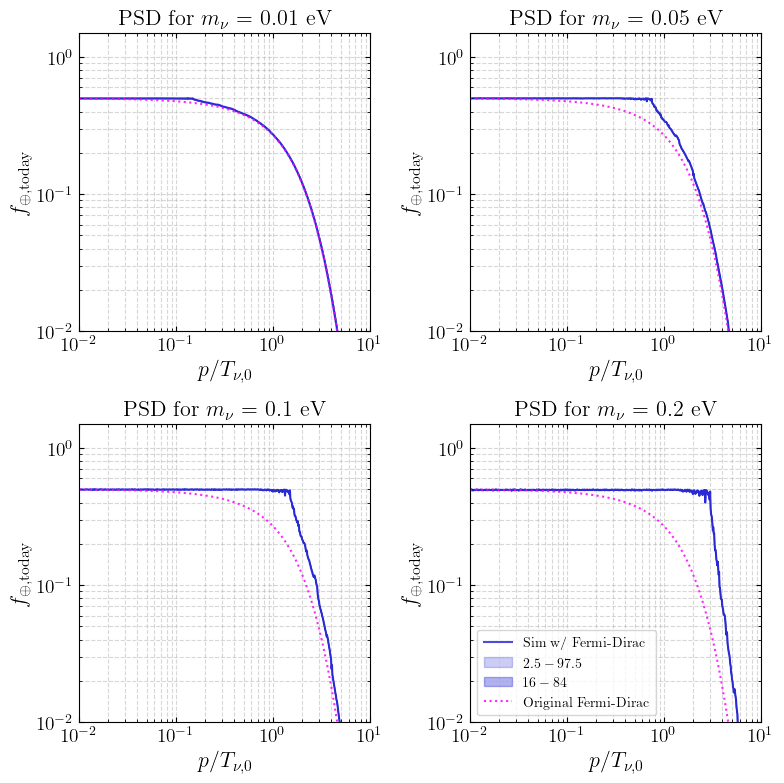

In [11]:
y_z0_median, FD_select = SimPlot.phase_space_2x2_FD_vs_PF(
    sim_dir=dens_folder, 
    m_picks=nu_m_picks, 
    halo_num=1, 
    fig_dir=fig_folder,
    args=Params())

(1000,)
(1000,)


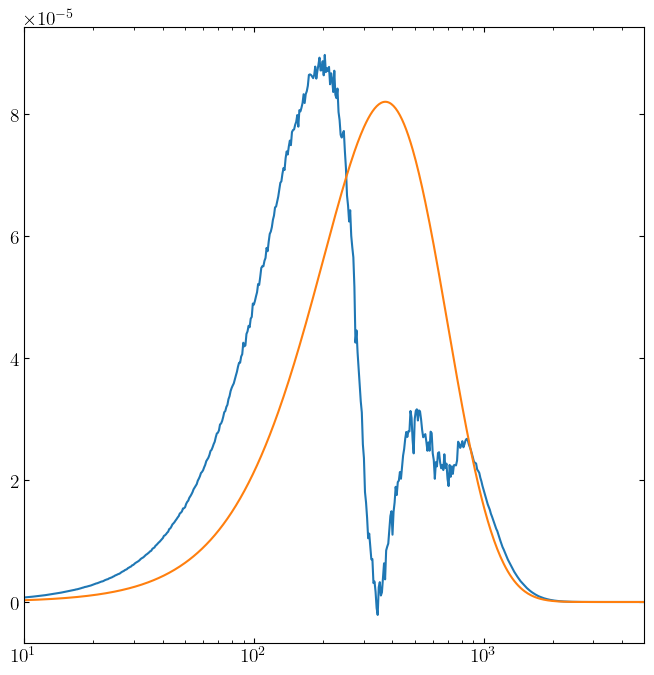

In [ ]:
# region: preamble
sim_name = f"SunMod_1k"
prefix = "SunMoveDop5_fin"
suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"
sim_folder = f"sim_output/{sim_name}"
fig_folder = f"figures_local/{sim_name}"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.15, 0.3])*Params.eV
simdata = SimData(sim_folder)


# Momentum array used in sims
p_arr = jnp.geomspace(
    simdata.p_start, simdata.p_stop, simdata.p_num)*Params.T_CNB

# Convert to velocity 
sim_mass = 0.3*Params.eV
v_arr = p_arr / sim_mass

# psd_arr = jnp.zeros_like(v_arr)
# Load psd array
psd_arr = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_psds{suffix}.npy")
# print(psd_arr.shape)
# shape: (days=31, halos=5, masses=5, npix=768, p_num=1000)

# Get PSD for days where modulation is max and min, select halo and mass
h_id = 0
m_id = 3
psd_max_m0p30 = psd_arr[jnp.argmin(jnp.abs(days_nums-173))][h_id, m_id, ...]
psd_min_m0p30 = psd_arr[jnp.argmin(jnp.abs(days_nums-356))][h_id, m_id, ...]
# print(psd_max_m0p30.shape)

f_dens_max = jnp.array(
    [jnp.sum(psd_max_m0p30[:,i]*v_arr[i]**2) for i in range(len(v_arr))])
f_dens_min = jnp.array(
    [jnp.sum(psd_min_m0p30[:,i]*v_arr[i]**2) for i in range(len(v_arr))])

# plt.semilogx(v_arr/(Params.km/Params.s), f_dens_max)
# plt.semilogx(v_arr/(Params.km/Params.s), f_dens_min)
# plt.semilogx(v_arr/(Params.km/Params.s), f_dens_max - f_dens_min)
# plt.semilogx(v_arr/(Params.km/Params.s), jnp.abs(f_dens_max - f_dens_min))


def fermi_dirac_vel(m, v):
    return m**3/(jnp.exp(m*v/Params.T_CNB)+1)

fd_arr = fermi_dirac_vel(sim_mass, v_arr)
print(fd_arr.shape)

fd_dens = jnp.array([jnp.sum(fd_arr[i]*v_arr[i]**2) for i in range(len(v_arr))])
print(fd_dens.shape)

plt.semilogx(v_arr/(Params.km/Params.s), (fd_dens*.69e5 - f_dens_max))
plt.semilogx(v_arr/(Params.km/Params.s), fd_dens*2e4)
plt.xlim(1e1, 5e3)

# endregion



# Plot daily sim psd vs. velocities
def plot_sampled_velocity_distributions(
        v_arr, psd_arr, nu_m_picks, fig_folder, unit_type="km/s", n_samples=100000, bin_num=50, pdf_str='vel_sampled_hist.pdf', 
        args=None):
    
    if args is None:
        args = Params()
    
    fig, ax = plt.figure(figsize=(10, 6)), plt.gca()
    
    colors = ['purple', 'blue']
    labels = [f'm_nu = {m/args.eV:.2f} eV' for m in nu_m_picks]
    
    # Set up bins based on unit type
    if unit_type == "km/s":
        bins = jnp.geomspace(1e1, 2e5, bin_num)
        ax.set_xlabel('v [km/s]')
        ax.set_xlim(3e1, 8e4)
    else:
        bins = jnp.geomspace(1e-4, 1, bin_num)
        ax.set_xlabel('v/c')
        ax.set_xlim(1e-5, 1)
    
    # Sample from each mass distribution and plot histograms
    for i, m in enumerate(nu_m_picks):
        # Compute Fermi-Dirac distribution
        # fd_dist = fermi_dirac_vel(m, v_arr)
        fd_dist = psd_arr[i]
        
        # Calculate weighted distribution for sampling (f*v^3)
        dist = fd_dist * v_arr**3
        
        # Calculate cumulative distribution for inverse sampling
        cum_dist = jnp.cumsum(dist)
        cum_dist = cum_dist / cum_dist[-1]
        
        # Generate random samples
        rand_vals = np.random.uniform(0, 1, n_samples)
        sampled_idx = jnp.searchsorted(cum_dist, rand_vals)
        v_sampled = v_arr[sampled_idx]
        
        # Convert to appropriate units for plotting
        if unit_type == "km/s":
            v_plot = v_sampled / (args.km/args.s)
        else:
            v_plot = v_sampled
        
        # Calculate statistics
        mean_v = jnp.mean(v_plot)
        std_v = jnp.std(v_plot)
        # print(f"Std^2:", std_v**2)
        # print(f"Variance in log space:", 10**jnp.var(jnp.log10(v_plot)))
        
        # Create histogram
        hist, _ = jnp.histogram(v_plot, bins=bins)
        
        # Plot histogram
        ax.step(bins[:-1], hist, where='post', color=colors[i], 
                label=f'{labels[i]}')
        
        # Plot mean and standard deviation
        ax.axvline(mean_v, color=colors[i], linestyle='--', 
                   label=f'Mean ({labels[i]}): {mean_v:.1f}')
        ax.axvspan(mean_v - std_v, mean_v + std_v, 
                   color=colors[i], alpha=0.2, 
                   label=r'1$\sigma$ range')


    ax.set_xscale('log')
    ax.set_ylabel('Counts')
    ax.set_title('Sampled Neutrino Velocity Distribution')
    ax.set_xlim(1e2, 1e4)
    ax.grid(True, which="both", linestyle=":")
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(f"{fig_folder}/{pdf_str}", bbox_inches="tight")
    plt.show()


# plot_sampled_velocity_distributions(
#     v_arr, 
#     jnp.max(psd_arr[idx_max, 0, ...], axis=-2),
#     nu_m_picks, 
#     fig_folder, 
#     unit_type="km/s", 
#     n_samples=200_000, 
#     bin_num=200, 
#     pdf_str='vel_sampled_hist.pdf',
#     args=None)

(3660, 1000)
(1000, 1000)
(1000, 1000)


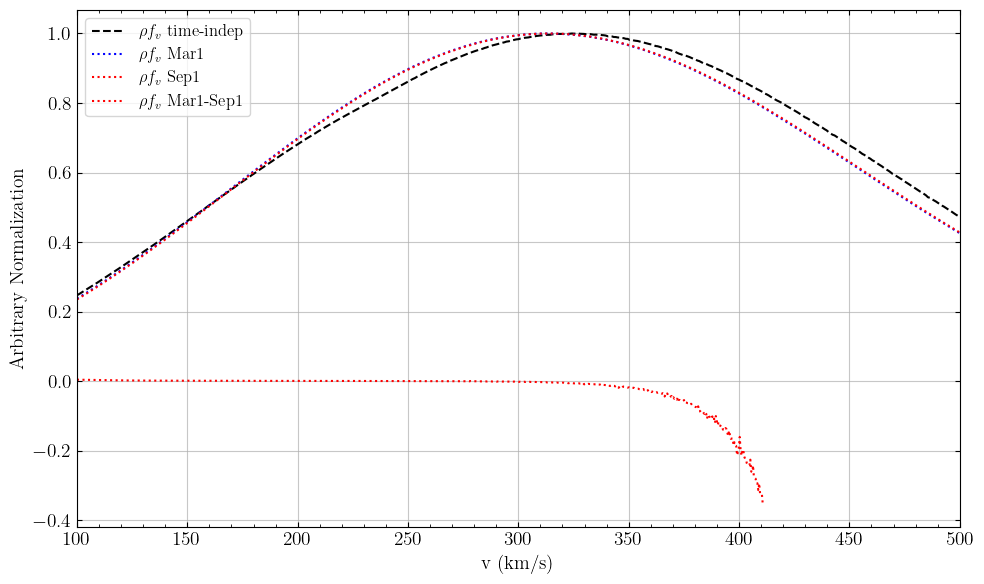

In [134]:
@jax.jit
def v_infinity(v_s, r_s):
    """
    Calculate the initial Solar-frame velocity for particles, s.t. they have velocity v_s at Earth's location.
    """
    
    v_GM = 2*Params.G*Params.Msun/jnp.linalg.norm(r_s, axis=-1)
    v_inf2 = jnp.linalg.norm(v_s, axis=-1)**2 - v_GM
    v_inf = jnp.sqrt(jnp.maximum(0, v_inf2))
    # v_inf = jnp.sqrt(v_inf2)
    r_s_unit = r_s / jnp.linalg.norm(r_s, axis=-1)
    vr_s_dot = jnp.dot(v_s, r_s_unit)

    numer = v_inf2[..., None]*v_s + v_inf[..., None]*v_GM/2*r_s_unit - v_inf[..., None]*v_s*vr_s_dot[..., None]
    denom = v_inf2 + v_GM/2 - v_inf*vr_s_dot
    
    return numer / denom[..., None]


def f_standard_halo_model(v_range, v_0, v_esc_MW, mode="time_indep"):
    
    v_unit = Params.km/Params.s
    # v_Sun = np.array([0.04420196,0.99859217,0.0293235])*251.19*v_unit
    v_Sun = jnp.array([11, 232, 7])*v_unit
    
    earth_positions = jnp.array(
        [pos for _, pos in SimUtil.calculate_earth_position(2024, mode="ecliptic")])*Params.AU
    earth_velocities = jnp.array(
        [vel for _, vel in SimUtil.calculate_earth_velocity(2024, mode="ecliptic")])*Params.km/Params.s

    main_key = Params.key

    num_rep = 1000

    if mode == "time_indep":
        zip_tup = zip(
            jnp.tile(earth_positions, (10,1)), 
            jnp.tile(earth_velocities, (10,1))
        )
    if mode == "Mar1":
        zip_tup = zip(
            jnp.tile(earth_positions[60], (num_rep,1)),
            jnp.tile(earth_velocities[60], (num_rep,1))
        )
    if mode == "Sep1":
        zip_tup = zip(
            jnp.tile(earth_positions[244], (num_rep,1)),
            jnp.tile(earth_velocities[244], (num_rep,1))
        )

    f_v_norm_l = []
    for r_s, e_vel in zip_tup:

        main_key, loop_key = jax.random.split(main_key)

        # v_nu = Utils.v_mag_to_xyz(v_range, loop_key)
        v_nu = Utils.v_mag_to_xyz_biased(
            v_range, loop_key, -v_Sun, cone_angle_rad=jnp.pi/12)
        
        v_s = v_nu + e_vel
        v_inf = v_infinity(v_s, r_s)
        v_for_f = v_inf + v_Sun
    
        v_for_f_mag = jnp.linalg.norm(v_for_f, axis=-1)

        # Create mask for velocity magnitudes smaller than escape velocity
        mask = v_for_f_mag < v_esc_MW

        # Compute standard halo model (SHM) distribution
        exp_term = jnp.exp(-v_for_f_mag**2/v_0**2)
        f_v = jnp.where(
            mask, 
            jnp.power(jnp.pi*v_0**2, -3/2) * exp_term, 
            jnp.zeros_like(exp_term))
        
        # Normalisation constant, and normalised velocity distribution
        z = v_esc_MW/v_0
        N_esc = jsp.special.erf(z) - 2/jnp.sqrt(jnp.pi)*z*jnp.exp(-z**2)
        f_v_normalized = f_v / N_esc

        f_v_norm_l.append(f_v_normalized)

    print(jnp.array(f_v_norm_l).shape)
    return jnp.max(jnp.array(f_v_norm_l), axis=0)


# region: plotting
plt.figure(figsize=(10, 6))

# p_range = jnp.geomspace(0.01, 400, 1_000) * Params.T_CNB
# v_range = p_range / sim_mass
v_range = jnp.linspace(100, 1000, 1000)*Params.km/Params.s

v_exp = 1

v_unit = Params.km/Params.s
v_0 = 220*v_unit
v_esc_MW = 550*v_unit
f_v = f_standard_halo_model(v_range, v_0, v_esc_MW)
f_v = f_v / trap(f_v, x=v_range)
rho_f_v = v_range**v_exp * f_v
#/ v^1 matches their curve, not v^2

plt.plot(
    v_range/v_unit, rho_f_v/jnp.max(rho_f_v), 'k--', label=r'$\rho f_v$ time-indep')

v_range = jnp.linspace(100, 500, 1000)*v_unit
f_v_Mar1 = f_standard_halo_model(v_range, v_0, v_esc_MW, mode="Mar1")
f_v_Mar1 = f_v_Mar1 / trap(f_v_Mar1, x=v_range)
rho_f_v_Mar1 = v_range**v_exp * f_v_Mar1

f_v_Sep1 = f_standard_halo_model(v_range, v_0, v_esc_MW, mode="Sep1")
f_v_Sep1 = f_v_Sep1 / trap(f_v_Sep1, x=v_range)
rho_f_v_Sep1 = v_range**v_exp * f_v_Sep1

# rho_f_v_diff = f_v_Mar1 - f_v_Sep1
rho_f_v_mod = (rho_f_v_Mar1 - rho_f_v_Sep1) / (2*rho_f_v)

plt.plot(
    v_range/v_unit, rho_f_v_Mar1/jnp.max(rho_f_v_Mar1), 'b:', 
    label=r'$\rho f_v$ Mar1')
plt.plot(
    v_range/v_unit, rho_f_v_Sep1/jnp.max(rho_f_v_Sep1), 'r:', 
    label=r'$\rho f_v$ Sep1')

# plt.plot(
#     v_range/v_unit, rho_f_v_diff/jnp.max(rho_f_v_diff), 'r:', 
#     label=r'$\rho f_v$ Mar1-Sep1')

plt.plot(
    v_range/v_unit, rho_f_v_mod, 'r:', 
    label=r'$\rho f_v$ Mar1-Sep1')

plt.xlabel('v (km/s)', fontsize=14)
plt.ylabel('Arbitrary Normalization', fontsize=14)
plt.xlim(100, 500)
plt.grid(True, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()
# endregion

(31, 1, 5, 768, 1000)


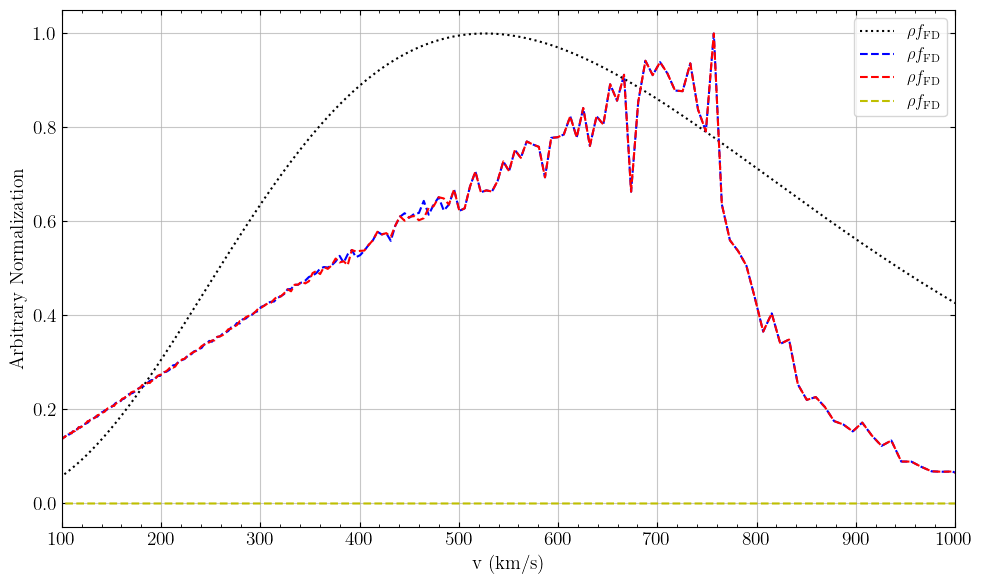

In [114]:
sim_name = f"SunMod_1k"
prefix = "SunMoveDop5_fin"
suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"
sim_folder = f"sim_output/{sim_name}"


# Momentum array used in sims
p_arr = jnp.geomspace(
    simdata.p_start, simdata.p_stop, simdata.p_num)*Params.T_CNB

# Convert to velocity 
sim_mass = 0.3*Params.eV
v_arr = p_arr / sim_mass


# Load psd array
days_nums = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_nums{suffix}.npy")
psd_arr = jnp.load(
    f"{sim_folder}/annual_densities_numerical/{prefix}_days_psds{suffix}.npy")
print(psd_arr.shape)

psd_plot1 = jnp.max(psd_arr, axis=-2)[jnp.argmin(jnp.abs(days_nums-356)),0,3]
psd_plot1 *= (v_arr**1 / trap(psd_plot1, x=jnp.log(v_arr)))

psd_plot2 = jnp.max(psd_arr, axis=-2)[jnp.argmin(jnp.abs(days_nums-173)),0,3]
psd_plot2 *= (v_arr**1 / trap(psd_plot2, x=jnp.log(v_arr)))
# shape: (days=31, halos=5, masses=5, npix=768, p_num=1000)

psd_diff = (psd_plot2/jnp.max(psd_plot2)) - (psd_plot1/jnp.max(psd_plot1))
psd_diff = (psd_plot2) - (psd_plot1)

def fermi_dirac_vel(m, v):
    return m**3/(jnp.exp(m*v/Params.T_CNB)+1)
fd_arr = fermi_dirac_vel(sim_mass, v_arr)
fd_arr *= (v_arr**3 / trap(fd_arr, x=jnp.log(v_arr)))
# print(3.15*Params.T_CNB/sim_mass/(Params.km/Params.s))


plt.figure(figsize=(10, 6))

plt.plot(
    v_arr/v_unit, fd_arr/jnp.max(fd_arr), 'k:', label=r'$\rho f_{\rm FD}$')

plt.plot(
    v_arr/v_unit, psd_plot1/jnp.max(psd_plot1), 'b--', label=r'$\rho f_{\rm FD}$')

plt.plot(
    v_arr/v_unit, psd_plot2/jnp.max(psd_plot2), 'r--', label=r'$\rho f_{\rm FD}$')

plt.plot(
    v_arr/v_unit, psd_diff, 'y--', label=r'$\rho f_{\rm FD}$')

plt.xlabel('v (km/s)', fontsize=14)
plt.ylabel('Arbitrary Normalization', fontsize=14)
plt.xlim(100, 1000)
plt.grid(True, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Deflection angles

In [ ]:
def calculate_deflection_angle(velocity_vectors):
    """
    Calculate the deflection angle between initial and final velocity vectors.
    
    :param velocity_vectors: numpy array of shape (N, 2, 3)
    :return: numpy array of deflection angles in degrees
    """
    z0_vels = velocity_vectors[:, 0, :]
    z4_vels = velocity_vectors[:, -1, :]
    
    # Normalize the vectors
    z0_vels_norm = z0_vels / np.linalg.norm(z0_vels, axis=-1)[:, None]
    z4_vels_norm = z4_vels / np.linalg.norm(z4_vels, axis=-1)[:, None]
    
    # Calculate the dot product
    dot_product = np.sum(z0_vels_norm * z4_vels_norm, axis=-1)
    
    # Clip the dot product to [-1, 1] to avoid numerical errors
    dot_product_clipped = np.clip(dot_product, -1.0, 1.0)
    
    # Calculate the angle in radians and convert to degrees
    angles = np.arccos(dot_product_clipped) * 180 / np.pi
    
    return angles


def analyze_and_plot_deflections(velocity_vectors, bins, exclude_zero):
    """
    Analyze deflection angles and create a plot with median and 1-sigma percentiles.
    The plot range is limited to the min and max found values.
    
    :param velocity_vectors: numpy array of shape (N, 2, 3)
    :param exclude_zero: boolean, if True, exclude zero angles from analysis
    """
    deflection_angles = calculate_deflection_angle(velocity_vectors)
    
    if exclude_zero:
        deflection_angles = deflection_angles[deflection_angles > 0]
        if len(deflection_angles) == 0:
            print("No non-zero deflection angles found. Cannot perform analysis.")
            return

    median = np.median(deflection_angles)
    percentile_16 = np.percentile(deflection_angles, 16)
    percentile_84 = np.percentile(deflection_angles, 84)
    # percentile_16 = np.percentile(deflection_angles, 2.5)
    # percentile_84 = np.percentile(deflection_angles, 97.5)
    
    min_angle = np.min(deflection_angles)
    max_angle = np.max(deflection_angles)
    
    plt.figure(figsize=(10, 6))
    n, bins, patches = plt.hist(deflection_angles, bins=bins, edgecolor='black')
    plt.axvline(
        median, color='r', linestyle='dashed', linewidth=2, 
        label=f'Median: {median:.2f}°')
    plt.axvline(
        percentile_16, color='g', linestyle='dashed', linewidth=2, 
        label=f'16th percentile: {percentile_16:.2f}°')
    plt.axvline(
        percentile_84, color='g', linestyle='dashed', linewidth=2, 
        label=f'84th percentile: {percentile_84:.2f}°')
    
    plt.xlabel('Deflection Angle (degrees)')
    plt.ylabel('Frequency')
    title = 'Distribution of Deflection Angles'
    if exclude_zero:
        title += ' (Excluding Zero Angles)'
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Set x-axis limits to min and max found values
    plt.xlim(min_angle, max_angle)
    
    # Adjust y-axis to show full height of the tallest bar
    plt.ylim(0, max(n) * 1.1)
    
    
    print(f"Median deflection angle: {median:.2f}°")
    print(f"1-sigma range: {percentile_16:.2f}° - {percentile_84:.2f}°")
    print(f"Minimum deflection angle: {min_angle:.2f}°")
    print(f"Maximum deflection angle: {max_angle:.2f}°")
    if exclude_zero:
        print(f"Number of non-zero angles: {len(deflection_angles)}")
        print(f"Number of zero angles excluded: {len(velocity_vectors) - len(deflection_angles)}")
    
    plt.show()
    

# """
for day in range(0, 365, 24)[::10]:

    # Load velocities for current day
    # Insert dimension at beginning to account for multiple halos later
    print(f"Day {day+1}")
    sim_folder_local = f"sim_output/SunMod_1k"
    days_vecs_dir = f"{sim_folder_local}/SunMove_Dopri5_New_wrtMW"
    day_vels = jnp.load(
        f"{days_vecs_dir}/vectors_day{day+1}.npy")[..., 3:].reshape(-1, 2, 3)

    analyze_and_plot_deflections(day_vels, bins=50, exclude_zero=True)
# """


"""
# For Dopri5_1k folder and DM halo files
for halo_i in range(3):

    print(f"Halo {halo_i+1}")
    # Load velocities for current day
    # Insert dimension at beginning to account for multiple halos later
    sim_folder_local = f"sim_output/Dopri5_1k"
    day_vels = jnp.load(
        f"{sim_folder_local}/vectors_halo{halo_i+1}.npy")[..., 3:].reshape(-1, 2, 3)

    analyze_and_plot_deflections(day_vels, bins=100, exclude_zero=True)
"""

In [ ]:
#
#? Questions?:
# - show that modulation curve peak is determined by relative velocity
# - virialisation/isotropy of bound CNB not good assumption?
#   and if all then for small percentage of [0.006, 0.7, 3.9, 12.4, 17.7]
#                                       for [0.01, 0.05, 0.1, 0.2,  0.3] eV